In [185]:
orderlines_expanded= 'https://drive.google.com/file/d/1ujSRmZAB2C0GIpLEXZQxZxQaP_7PN0H8/view?usp=drive_link'

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)


In [186]:
import pandas as pd

orders_url = "https://drive.google.com/file/d/1peIPjT6MIEkxWODSl61541ggCTQsgnTT/view?usp=drive_link"
orderlines_url = "https://drive.google.com/file/d/1bknWYsDEZaUL9TjoAglmBG82bZNxicCu/view?usp=drive_link"
products_url = "https://drive.google.com/file/d/1QwKQQfWFkNcvTksbRvLa87h_fPgqkfTm/view?usp=drive_link"
brands_url = "https://drive.google.com/file/d/1lcXSZLdDQwYGmsGinazigsOuXu0_N8mm/view?usp=drive_link"

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)

# Importing csvs and correcting data types
orderlines_qu = import_csv(orderlines_url)
orderlines_qu['date'] = pd.to_datetime(orderlines_qu['date'])
orders_qu = import_csv(orders_url)
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])
products_cl = import_csv(products_url)
brands_cl = import_csv(brands_url)

# Incorporating additional information into orderlines data frame
orderlines_qu['short'] = orderlines_qu['sku'].str[:3]
orderlines_expanded = (
    orderlines_qu
    .merge(products_cl, on='sku')
    .merge(brands_cl, on='short')
    .rename(columns={'long': 'brand'})
    .drop(columns=['short'])
)
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)

In [187]:
orderlines_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53195 entries, 0 to 53194
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   53195 non-null  int64         
 1   id_order             53195 non-null  int64         
 2   product_id           53195 non-null  int64         
 3   product_quantity     53195 non-null  int64         
 4   sku                  53195 non-null  object        
 5   unit_price           53195 non-null  float64       
 6   date                 53195 non-null  datetime64[ns]
 7   name                 53195 non-null  object        
 8   desc                 53195 non-null  object        
 9   price                53195 non-null  float64       
 10  in_stock             53195 non-null  int64         
 11  type                 53184 non-null  object        
 12  brand                53195 non-null  object        
 13  revenue              53195 non-

In [188]:

orders_qu["created_date"].min()

Timestamp('2017-01-01 01:51:47')

In [189]:

orders_qu["created_date"].max()

Timestamp('2018-03-14 12:03:52')

In [190]:
orders_qu

,order_id,created_date,total_paid,state
0,241423,2017-11-06 13:10:02,136.15,Completed
1,242832,2017-12-31 17:40:03,15.76,Completed
2,243330,2017-02-16 10:59:38,84.98,Completed
3,245275,2017-06-28 11:35:37,149.00,Completed
4,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...
40980,527042,2018-03-14 11:47:50,18.98,Completed
40981,527070,2018-03-14 11:50:48,24.97,Completed
40982,527074,2018-03-14 11:51:42,24.97,Completed
40983,527096,2018-03-14 11:58:40,34.96,Completed


In [191]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=orders_qu)

https://docs.google.com/spreadsheets/d/1tkZ3_E9E4C_L6ZzWx-xXHyY0vwonFIeTwd9iSFSUjC8/edit#gid=0


In [192]:
orders_qu['month_name'] = orders_qu["created_date"].dt.strftime('%b')

In [193]:
avg_month_orders = orders_qu.groupby("month_name",as_index=False)["total_paid"].mean().round(2)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
avg_month_orders = avg_month_orders.set_index('month_name').reindex(month_order).reset_index()
avg_month_orders

,month_name,total_paid
0,Jan,164.84
1,Feb,177.07
2,Mar,166.92
3,Apr,158.22
4,May,202.26
5,Jun,219.90
6,Jul,198.61
7,Aug,183.94
8,Sep,210.62
9,Oct,201.63


## Buisness Questions:-


What is the time period that the dataset covers?

What is the overall revenue for that time?

Are there seasonal patterns in the evolution of sales?

What are the most sold products?

What are the products that generate the most revenue?


In [184]:
product_category_df=products_cl.copy()

In [194]:
orderlines_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53195 entries, 0 to 53194
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   53195 non-null  int64         
 1   id_order             53195 non-null  int64         
 2   product_id           53195 non-null  int64         
 3   product_quantity     53195 non-null  int64         
 4   sku                  53195 non-null  object        
 5   unit_price           53195 non-null  float64       
 6   date                 53195 non-null  datetime64[ns]
 7   name                 53195 non-null  object        
 8   desc                 53195 non-null  object        
 9   price                53195 non-null  float64       
 10  in_stock             53195 non-null  int64         
 11  type                 53184 non-null  object        
 12  brand                53195 non-null  object        
 13  revenue              53195 non-

In [195]:
# Create hierarchy columns
product_category_df["main_category"] = "Other Products"
product_category_df["sub_category"] = "Uncategorized"


# 1. Mobile Devices
product_category_df.loc[
    product_category_df["name"].str.contains("iphone", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Mobile Devices", "Smartphones"]

product_category_df.loc[
    product_category_df["name"].str.contains("ipad|tablet", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Mobile Devices", "Tablets"]

product_category_df.loc[
    product_category_df["name"].str.contains("ipod", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Mobile Devices", "iPod"]


# 2. Computers
product_category_df.loc[
    product_category_df["name"].str.contains("macbook", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Computers", "Laptops"]

product_category_df.loc[
    product_category_df["name"].str.contains("imac|mac mini|mac pro", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Computers", "Desktops"]

product_category_df.loc[
    product_category_df["desc"].str.contains("ram", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Computers", "Components"]


# 3. Storage
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "ssd|hard drive|hard disk|flash drive|memory|storage",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Storage", "SSD & Drives"]


# 4. Accessories
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "keyboard|mouse|trackpad",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Accessories", "Keyboard & Mouse"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "cable|connector|adapter",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Accessories", "Cables & Adapters"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "charger|dock|hub",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Accessories", "Chargers & Docks"]


# 5. Protection
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "case|cover|housing|casing|sleeve|shell|protect",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Protection", "Cases & Covers"]


# 6. Audio
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "headset|headphones",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Audio", "Headphones"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "speaker|music system",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Audio", "Speakers"]


# 7. Wearables
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "apple watch|smartwatch|smart watch",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Wearables", "Smartwatch"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "strap|armband|belt|bracelet",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Wearables", "Watch Straps"]


# 8. Electronics
product_category_df.loc[
    product_category_df["desc"].str.contains("monitor", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Electronics", "Monitors"]

product_category_df.loc[
    product_category_df["desc"].str.contains("camera", case=False, na=False),
    ["main_category", "sub_category"]
] = ["Electronics", "Cameras"]


# 9. Networking
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "nas|server|raid|synology",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Networking", "NAS & Servers"]


# 10. Other Products
product_category_df.loc[
    product_category_df["desc"].str.contains(
        "backpack",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Other Products", "Bags"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "scale|thermometer",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Other Products", "Measurement Devices"]

product_category_df.loc[
    product_category_df["desc"].str.contains(
        "refurbished|reconditioned|like new",
        case=False,
        na=False
    ),
    ["main_category", "sub_category"]
] = ["Other Products", "Refurbished"]


# Group result
product_category_df.groupby("main_category")["sub_category"].value_counts()

main_category   sub_category       
Accessories     Cables & Adapters       592
                Chargers & Docks        238
                Keyboard & Mouse         66
Audio           Speakers                165
                Headphones              150
Computers       Components              669
                Laptops                 158
                Desktops                137
Electronics     Monitors                275
                Cameras                 115
Mobile Devices  Smartphones             460
                Tablets                 362
                iPod                     64
Networking      NAS & Servers          1044
Other Products  Uncategorized           963
                Refurbished             519
                Measurement Devices      89
                Bags                     57
Protection      Cases & Covers         1890
Storage         SSD & Drives           1543
Wearables       Watch Straps            249
                Smartwatch              187
Name: count, dtype: int64

In [196]:
orderlines_expanded = (orderlines_qu.merge(product_category_df, on='sku').merge(brands_cl, on='short').rename(columns={'long': 'brand'}).drop(columns=['short']))

In [197]:


# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)

In [198]:
orderlines_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53195 entries, 0 to 53194
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   53195 non-null  int64         
 1   id_order             53195 non-null  int64         
 2   product_id           53195 non-null  int64         
 3   product_quantity     53195 non-null  int64         
 4   sku                  53195 non-null  object        
 5   unit_price           53195 non-null  float64       
 6   date                 53195 non-null  datetime64[ns]
 7   name                 53195 non-null  object        
 8   desc                 53195 non-null  object        
 9   price                53195 non-null  float64       
 10  in_stock             53195 non-null  int64         
 11  type                 53184 non-null  object        
 12  main_category        53195 non-null  object        
 13  sub_category         53195 non-

In [199]:
# By category
revenue_by_category = orderlines_expanded.groupby('main_category')['revenue'].sum().sort_values(ascending=False)
print(revenue_by_category)

main_category
Mobile Devices    1845861.93
Storage           1519186.07
Other Products     937598.39
Networking         789128.77
Electronics        759671.95
Computers          586031.47
Accessories        457095.30
Audio              333024.83
Wearables          299461.40
Protection         284549.18
Name: revenue, dtype: float64


In [200]:
# By category
revenue_by_category = orderlines_expanded.groupby('main_category')['revenue'].sum().sort_values(ascending=False)
print(revenue_by_category)

main_category
Mobile Devices    1845861.93
Storage           1519186.07
Other Products     937598.39
Networking         789128.77
Electronics        759671.95
Computers          586031.47
Accessories        457095.30
Audio              333024.83
Wearables          299461.40
Protection         284549.18
Name: revenue, dtype: float64


In [201]:
#Monthly Percentage Discount
monthly_discount1 = orderlines_expanded.set_index('date').resample('ME')['percentage_discount'].mean().round(2)
print(monthly_discount1)

date
2017-01-31    24.81
2017-02-28    19.58
2017-03-31    18.96
2017-04-30    18.30
2017-05-31    15.30
2017-06-30    17.41
2017-07-31    24.91
2017-08-31    20.54
2017-09-30    20.12
2017-10-31    21.98
2017-11-30    21.94
2017-12-31    19.38
2018-01-31    22.02
2018-02-28    21.78
2018-03-31    22.08
Freq: ME, Name: percentage_discount, dtype: float64


In [202]:
#Average order Value
monthly_summary = orderlines_expanded.set_index('date').resample('ME').agg(
    revenue=('revenue', 'sum'),
    orders=('id_order', 'nunique'),
    avg_discount=('percentage_discount', 'mean')
)
monthly_summary['Average_Order_Value'] = monthly_summary['revenue'] / monthly_summary['orders']
print(monthly_summary)

               revenue  orders  avg_discount  Average_Order_Value
date                                                             
2017-01-31   608825.74    4620     24.808062           131.780463
2017-02-28   327344.61    2026     19.583188           161.571871
2017-03-31    25508.97     168     18.956547           151.839107
2017-04-30   230104.56    1468     18.299163           156.746975
2017-05-31   331725.55    1661     15.304875           199.714359
2017-06-30   285107.03    1345     17.414147           211.975487
2017-07-31   602544.27    3080     24.911251           195.631256
2017-08-31   376129.63    2095     20.538626           179.536816
2017-09-30   393137.39    1900     20.116457           206.914416
2017-10-31   546188.25    2766     21.979018           197.465022
2017-11-30  1501665.97    6270     21.938415           239.500155
2017-12-31   985027.95    4859     19.381945           202.722361
2018-01-31   856727.41    4501     22.022222           190.341571
2018-02-28

In [203]:
product_category_df.groupby('main_category')["sub_category"].value_counts()

main_category   sub_category       
Accessories     Cables & Adapters       592
                Chargers & Docks        238
                Keyboard & Mouse         66
Audio           Speakers                165
                Headphones              150
Computers       Components              669
                Laptops                 158
                Desktops                137
Electronics     Monitors                275
                Cameras                 115
Mobile Devices  Smartphones             460
                Tablets                 362
                iPod                     64
Networking      NAS & Servers          1044
Other Products  Uncategorized           963
                Refurbished             519
                Measurement Devices      89
                Bags                     57
Protection      Cases & Covers         1890
Storage         SSD & Drives           1543
Wearables       Watch Straps            249
                Smartwatch              187
Name: count, dtype: int64

In [204]:
discount_by_category = (
    orderlines_expanded
    .groupby("main_category")["percentage_discount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

discount_by_category

,main_category,percentage_discount
0,Protection,31.080070
1,Audio,26.890901
2,Accessories,24.211628
3,Other Products,22.730249
4,Wearables,20.770887
5,Electronics,19.940873
6,Storage,17.824895
7,Computers,16.372706
8,Mobile Devices,14.449536
9,Networking,13.213908


In [205]:
discount_by_category=(orderlines_expanded.groupby("main_category")["percentage_discount"].mean().sort_values(ascending=False).reset_index())

discount_by_category

,main_category,percentage_discount
0,Protection,31.080070
1,Audio,26.890901
2,Accessories,24.211628
3,Other Products,22.730249
4,Wearables,20.770887
5,Electronics,19.940873
6,Storage,17.824895
7,Computers,16.372706
8,Mobile Devices,14.449536
9,Networking,13.213908


In [206]:
high_discount = orderlines_expanded[
    orderlines_expanded['percentage_discount'] > 80
]

high_discount_count = len(high_discount)

print(f"Number of order lines with more than 80% discount: {high_discount_count}")

Number of order lines with more than 80% discount: 335


In [207]:
total_discount = orderlines_expanded['total_discount'].sum()

print(f"Total Discount Given: €{total_discount:,.2f}")

Total Discount Given: €1,524,159.00


In [208]:
total_orders = orders_qu['order_id'].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 40,985


In [209]:
total_products = orderlines_expanded['sku'].nunique()

# Unique products that had a discount
discounted_products = (orderlines_expanded[orderlines_expanded['percentage_discount'] > 0]['sku'].nunique())

# Percentage of products discounted
percentage_discounted_products = (
    discounted_products / total_products
) * 100


print(f"Total products sold: {total_products:,}")
print(f"Products discounted : {discounted_products:,}")
print(f"Percentage of products discounted: {percentage_discounted_products:.1f}%")

Total products sold: 5,079
Products discounted : 4,888
Percentage of products discounted: 96.2%


In [210]:
non_discounted_products = total_products - discounted_products

print("Products never discounted:", non_discounted_products)

Products never discounted: 191


In [211]:
# Only consider discounted products
discounted_sales = orderlines_expanded[
    orderlines_expanded['percentage_discount'] > 0
]

average_discount = discounted_sales['percentage_discount'].mean()
median_discount = discounted_sales['percentage_discount'].median()

print(f"Average discount: {average_discount:.1f}%")
print(f"Median discount: {median_discount:.1f}%")

Average discount: 23.2%
Median discount: 19.6%


In [212]:
discount_bins = pd.cut(
    discounted_sales['percentage_discount'],
    bins=[0,10,20,30,50,100],
    labels=[
        '0-10%',
        '10-20%',
        '20-30%',
        '30-50%',
        '50%+'
    ]
)

discount_distribution = (
    discount_bins
    .value_counts()
    .sort_index()
)

discount_distribution

,count
percentage_discount,
0-10%,10497
10-20%,15172
20-30%,11424
30-50%,7303
50%+,4973


In [213]:
total_revenue = orderlines_expanded['revenue'].sum()
print(total_revenue)

7811609.289999999


In [214]:
category_discount = (
    orderlines_expanded
    .groupby('main_category')
    .agg(
        avg_discount=('percentage_discount', 'mean'),
        total_discount=('total_discount', 'sum'),
        number_of_orders=('id_order', 'count')
    )
    .sort_values('avg_discount', ascending=False)
)

category_discount

,avg_discount,total_discount,number_of_orders
main_category,,,
Protection,31.080070,129317.15,7465
Audio,26.890901,93172.00,2924
Accessories,24.211628,119820.30,8433
Other Products,22.730249,261721.99,7739
Wearables,20.770887,39746.14,2174
Electronics,19.940873,154613.70,2245
Storage,17.824895,306048.21,8540
Computers,16.372706,121720.62,5036
Mobile Devices,14.449536,183106.09,6343


In [215]:
orders_qu["quarter"] = orders_qu["created_date"].dt.to_period("Q")
orders_qu["quarter"]

,quarter
0,2017Q4
1,2017Q4
2,2017Q1
3,2017Q2
4,2017Q1
...,...
40980,2018Q1
40981,2018Q1
40982,2018Q1
40983,2018Q1


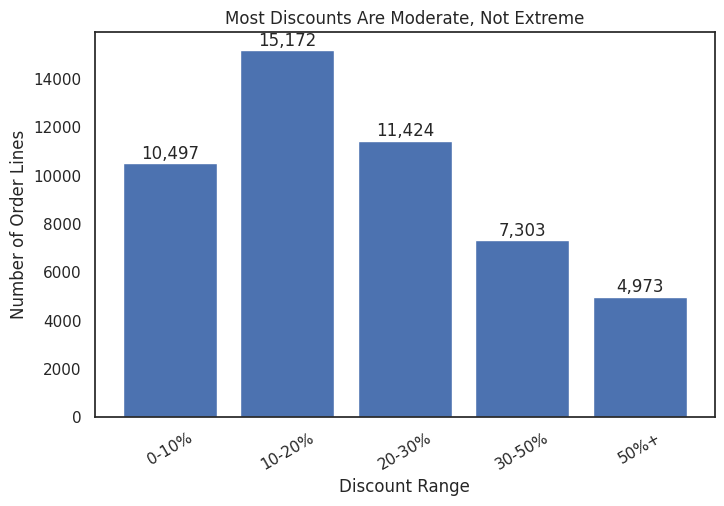

In [216]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    discount_distribution.index,
    discount_distribution.values
)

plt.xlabel("Discount Range")
plt.ylabel("Number of Order Lines")
plt.title("Most Discounts Are Moderate, Not Extreme")

for i, value in enumerate(discount_distribution.values):
    plt.text(
        i,
        value + 200,
        f"{value:,}",
        ha='center'
    )

plt.xticks(rotation=30)
plt.show()

In [217]:
# Merge orders information to get created_date
orderlines_expanded = orderlines_expanded.merge(
    orders_qu[['order_id', 'created_date']],
    left_on='id_order',
    right_on='order_id',
    how='left'
)

# Convert date column
orderlines_expanded['created_date'] = pd.to_datetime(
    orderlines_expanded['created_date']
)


# Monthly summary
monthly_summary = (
    orderlines_expanded
    .groupby(orderlines_expanded['created_date'].dt.to_period('M'))
    .agg(
        total_revenue=('revenue', 'sum'),
        average_orderline_revenue=('revenue', 'mean'),
        average_discount=('percentage_discount', 'mean'),
        total_order_lines=('id_order', 'count'),
        total_orders=('id_order', 'nunique')
    )
)

# Convert month format
monthly_summary.index = monthly_summary.index.astype(str)

monthly_summary.round(2)

,total_revenue,average_orderline_revenue,average_discount,total_order_lines,total_orders
created_date,,,,,
2017-01,603656.91,100.56,24.87,6003,4592
2017-02,332473.45,128.02,19.51,2597,2042
2017-03,24856.02,115.61,19.05,215,163
2017-04,227815.87,121.57,18.27,1874,1459
2017-05,331214.98,154.20,15.40,2148,1651
2017-06,286575.67,165.36,17.16,1733,1329
2017-07,598824.97,144.89,24.99,4133,3070
2017-08,379360.33,140.45,20.50,2701,2097
2017-09,387942.85,156.68,20.02,2476,1880


In [218]:
# Convert date column
orderlines_expanded['created_date'] = pd.to_datetime(
    orderlines_expanded['created_date']
)

# Monthly analysis
monthly_discount_analysis = (
    orderlines_expanded
    .groupby(orderlines_expanded['created_date'].dt.to_period('M'))
    .agg(
        total_revenue=('revenue', 'sum'),
        total_discount_given=('total_discount', 'sum'),
        average_discount=('percentage_discount', 'mean'),
        total_orders=('id_order', 'nunique')
    )
)

# Convert month format
monthly_discount_analysis.index = (
    monthly_discount_analysis.index.astype(str)
)

# Round values
monthly_discount_analysis = monthly_discount_analysis.round(2)

monthly_discount_analysis

,total_revenue,total_discount_given,average_discount,total_orders
created_date,,,,
2017-01,603656.91,143873.42,24.87,4592
2017-02,332473.45,58916.22,19.51,2042
2017-03,24856.02,3524.70,19.05,163
2017-04,227815.87,37607.84,18.27,1459
2017-05,331214.98,48068.82,15.40,1651
2017-06,286575.67,48815.26,17.16,1329
2017-07,598824.97,131682.88,24.99,3070
2017-08,379360.33,80974.99,20.50,2097
2017-09,387942.85,69491.73,20.02,1880


In [219]:
import pandas as pd

orders_url = "https://drive.google.com/file/d/1peIPjT6MIEkxWODSl61541ggCTQsgnTT/view?usp=drive_link"
orderlines_url = "https://drive.google.com/file/d/1bknWYsDEZaUL9TjoAglmBG82bZNxicCu/view?usp=drive_link"
products_url = "https://drive.google.com/file/d/1QwKQQfWFkNcvTksbRvLa87h_fPgqkfTm/view?usp=drive_link"
brands_url = "https://drive.google.com/file/d/1lcXSZLdDQwYGmsGinazigsOuXu0_N8mm/view?usp=drive_link"

def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)

# Importing csvs and correcting data types
orderlines_qu = import_csv(orderlines_url)
orderlines_qu['date'] = pd.to_datetime(orderlines_qu['date'])
orders_qu = import_csv(orders_url)
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])
products_cl = import_csv(products_url)
brands_cl = import_csv(brands_url)

# Incorporating additional information into orderlines data frame
orderlines_qu['short'] = orderlines_qu['sku'].str[:3]
orderlines_expanded = (
    orderlines_qu
    .merge(products_cl, on='sku')
    .merge(brands_cl, on='short')
    .rename(columns={'long': 'brand'})
    .drop(columns=['short'])
)
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)



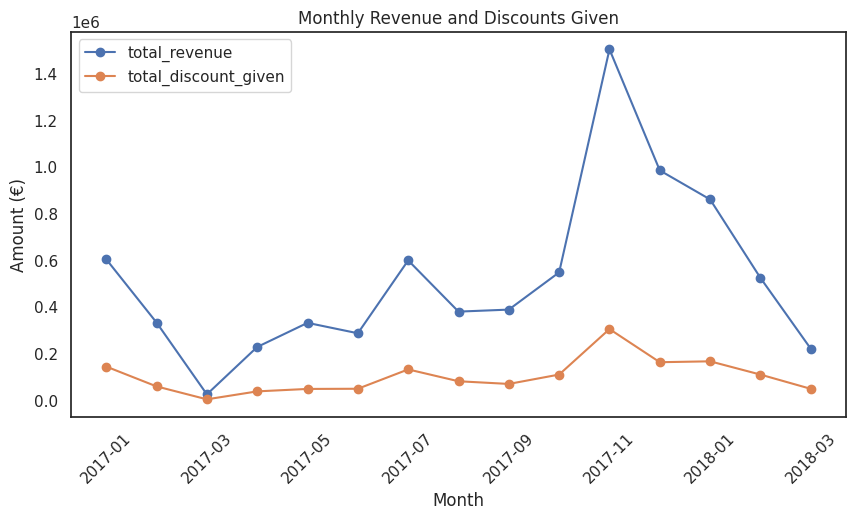

In [220]:
import matplotlib.pyplot as plt

monthly_discount_analysis[['total_revenue',
                           'total_discount_given']].plot(
    figsize=(10,5),
    marker='o'
)

plt.title(
    "Monthly Revenue and Discounts Given"
)

plt.xlabel("Month")
plt.ylabel("Amount (€)")

plt.xticks(rotation=45)

plt.show()

In [221]:
orders_qu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40985 entries, 0 to 40984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40985 non-null  int64         
 1   created_date  40985 non-null  datetime64[ns]
 2   total_paid    40985 non-null  float64       
 3   state         40985 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.3+ MB


In [222]:
orderlines_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53195 entries, 0 to 53194
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   53195 non-null  int64         
 1   id_order             53195 non-null  int64         
 2   product_id           53195 non-null  int64         
 3   product_quantity     53195 non-null  int64         
 4   sku                  53195 non-null  object        
 5   unit_price           53195 non-null  float64       
 6   date                 53195 non-null  datetime64[ns]
 7   name                 53195 non-null  object        
 8   desc                 53195 non-null  object        
 9   price                53195 non-null  float64       
 10  in_stock             53195 non-null  int64         
 11  type                 53184 non-null  object        
 12  brand                53195 non-null  object        
 13  revenue              53195 non-

In [223]:
import pandas as pd

# Merge orders information to get created_date
orderlines_expanded = orderlines_expanded.merge(
    orders_qu[['order_id', 'created_date']],
    left_on='id_order',
    right_on='order_id',
    how='left'
)

# Convert date column to datetime
orderlines_expanded['created_date'] = pd.to_datetime(orderlines_expanded['created_date'])

# Monthly summary
monthly_summary = (
    orderlines_expanded
    .groupby(orderlines_expanded['created_date'].dt.to_period('M'))
    .agg(
        total_revenue=('revenue', 'sum'),
        average_orderline_revenue=('revenue', 'mean'),
        average_discount=('percentage_discount', 'mean'),
        total_order_lines=('id_order', 'count'),
        total_orders=('id_order', 'nunique')
    )
)

# Convert month format to string
monthly_summary.index = monthly_summary.index.astype(str)

# Apply rounding
monthly_summary = monthly_summary.round(2)

In [224]:
monthly_summary

,total_revenue,average_orderline_revenue,average_discount,total_order_lines,total_orders
created_date,,,,,
2017-01,603656.91,100.56,24.87,6003,4592
2017-02,332473.45,128.02,19.51,2597,2042
2017-03,24856.02,115.61,19.05,215,163
2017-04,227815.87,121.57,18.27,1874,1459
2017-05,331214.98,154.20,15.40,2148,1651
2017-06,286575.67,165.36,17.16,1733,1329
2017-07,598824.97,144.89,24.99,4133,3070
2017-08,379360.33,140.45,20.50,2701,2097
2017-09,387942.85,156.68,20.02,2476,1880


In [225]:
# Create discount buckets
orderlines_expanded['discount_size'] = pd.cut(
    orderlines_expanded['percentage_discount'],
    bins=[-1, 5, 15, 25, 35, float('inf')],
    labels=['0-5%', '5-15%', '15-25%', '25-35%', '35%+']
)

# Calculate number of orders and revenue share by discount size
discount_analysis = (
    orderlines_expanded
    .groupby('discount_size', observed=False)
    .agg(
        number_of_orders=('id_order', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

# Calculate percentages
discount_analysis['% of all orders'] = (
    discount_analysis['number_of_orders'] /
    discount_analysis['number_of_orders'].sum() * 100
).round(1)

discount_analysis['% of all revenue'] = (
    discount_analysis['revenue'] /
    discount_analysis['revenue'].sum() * 100
).round(1)

discount_analysis

,discount_size,number_of_orders,revenue,% of all orders,% of all revenue
0,0-5%,6879,1862185.19,14.3,24.6
1,5-15%,12780,2597829.93,26.6,34.4
2,15-25%,12695,1973908.94,26.5,26.1
3,25-35%,7264,753753.85,15.1,10.0
4,35%+,8339,368718.11,17.4,4.9


In [226]:
orderlines_expanded['date'] = pd.to_datetime(orderlines_expanded['date'])
orderlines_expanded['month'] = orderlines_expanded['date'].dt.to_period('M')

order_summary = orderlines_expanded.groupby(['month', 'id_order']).agg(
    total_units=('product_quantity', 'sum')
).reset_index()

monthly_avg_df = order_summary.groupby('month').agg(
    avg_units=('total_units', 'mean')
).reset_index()

monthly_avg_df['Month'] = monthly_avg_df['month'].dt.strftime('%b %Y')
monthly_avg_df['Average Items per Order'] = monthly_avg_df['avg_units'].round(2)

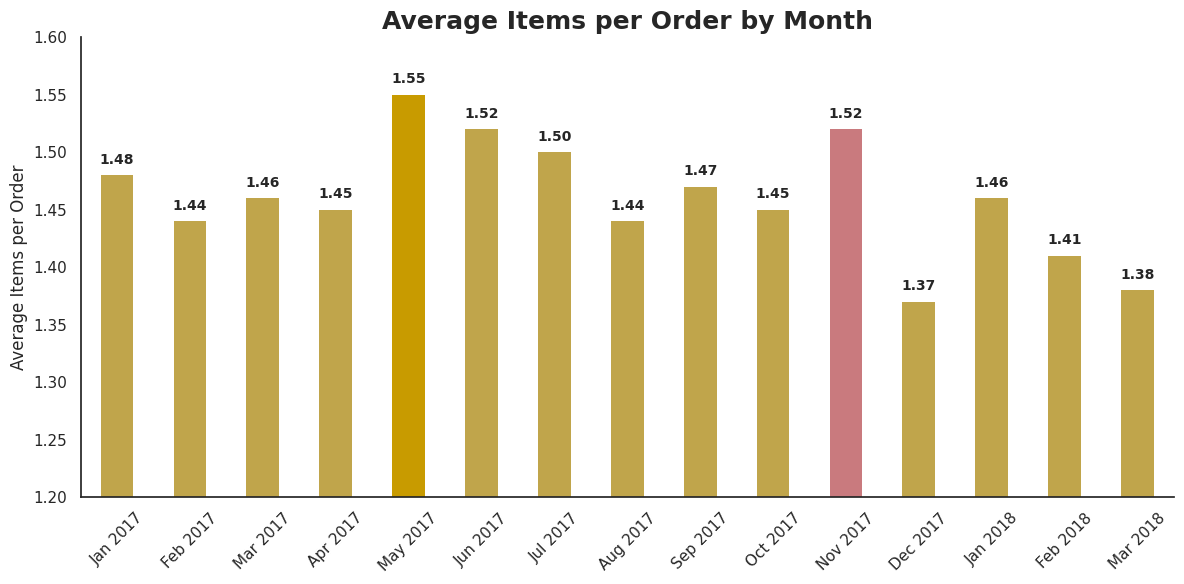

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Light yellow for all months
ax = sns.barplot(
    data = monthly_avg_df,
    x='Month',
    y='Average Items per Order',
    color='#D4AF37',      # Soft light yellow
    width=0.45,
    edgecolor='none'
)

# Highlight May (highest average items per order)
ax.patches[4].set_facecolor('#C89B00')    # Dark golden yellow

# Highlight Nov (Black Friday)
ax.patches[10].set_facecolor('#C97A7E')   # Light berry red

# Labels
plt.title('Average Items per Order by Month', fontsize=18, fontweight='bold')
plt.ylabel('Average Items per Order', fontsize=12)
plt.xlabel('')
plt.ylim(1.2, 1.6)

plt.xticks(rotation=45)

sns.despine()
plt.grid(False)

# Value labels
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [228]:
most_sold = (
    orderlines_expanded
    .groupby('name', as_index=False)['product_quantity']
    .sum()
    .rename(columns={'product_quantity': 'Units Sold'})
    .sort_values('Units Sold', ascending=False)
)

most_sold.head(10)

,name,Units Sold
1479,IPhone AppleCare Protection Plan,955
217,Apple Lightning Cable Connector to USB 1m Whit...,820
135,AirPods Apple Bluetooth Headset for iPhone iPa...,537
1075,EarPods Apple Headphones with Remote and Mic (...,489
3709,"Red 4TB WD 35 ""Mac PC hard drive and NAS",476
3756,Samsung 850 EVO SSD Disk 500GB,329
897,Crucial MX300 525GB SSD Disk,328
456,Apple iPhone 6 32GB Space Gray,270
88,"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",252
893,Crucial MX300 275GB SSD Disk,248


In [229]:
top_brands = (
    orderlines_expanded
    .groupby('brand')['product_quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_brands.head(10)

,brand,product_quantity
0,Apple,11156
1,OWC,3857
2,Western Digital,2404
3,Belkin,2279
4,LaCie,2130
5,Crucial,2070
6,Satechi,1824
7,Wacom,1816
8,Pack,1710
9,NewerTech,1648


In [230]:
top_revenue = (
    orderlines_expanded
    .groupby('name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_revenue.head(10)

,name,revenue
0,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83
1,Apple iPhone 6 32GB Space Gray,104560.64
2,AirPods Apple Bluetooth Headset for iPhone iPa...,86473.26
3,Apple iPhone 64GB Space Gray 8,85301.93
4,Apple iPhone 32GB Space Gray,80715.76
5,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",74964.06
6,Apple iPhone 8 Plus 64GB Gold,70721.79
7,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96
8,Apple iPhone 8 Plus 64GB Space Gray,60090.08
9,Apple iPhone 64GB Gold 8,52981.19


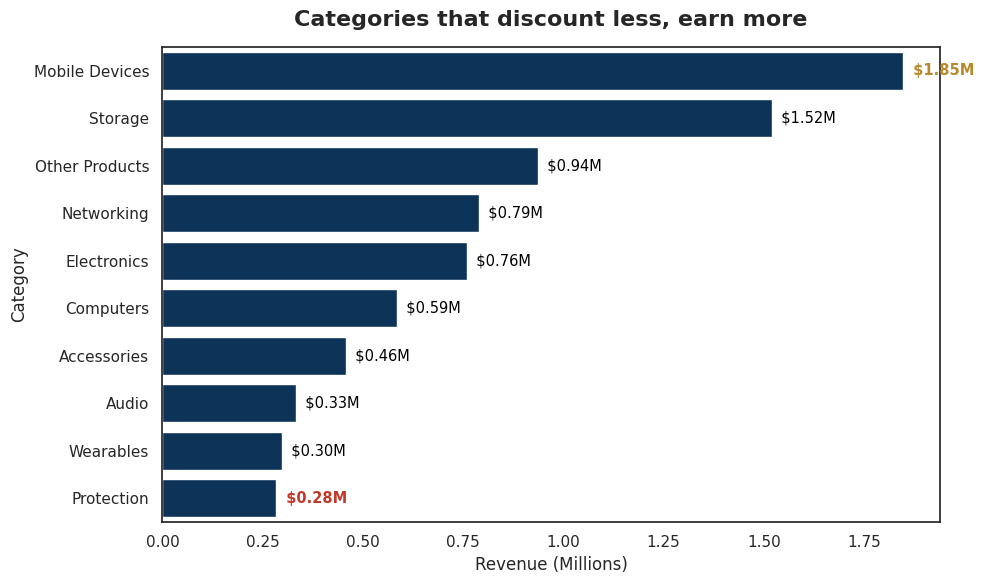

In [231]:
from google.colab import sheets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Your existing code to load the CSV
orderlines_expanded = "https://drive.google.com/file/d/1ujSRmZAB2C0GIpLEXZQxZxQaP_7PN0H8/view?usp=drive_link"
def import_csv(url):
    path = (
        "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
    )
    return pd.read_csv(path)
df = import_csv(orderlines_expanded)
# Group by main_category: sum revenue and average discount
stats = df.groupby("main_category").agg(
    revenue=("revenue", "sum"), discount=("discount", "mean")
).sort_values("revenue", ascending=False)
# Format revenue and discount for display
stats["revenue_formatted"] = stats["revenue"].apply(lambda x: f"${x/1e6:.2f}M")
stats["discount_formatted"] = stats["discount"].apply(lambda x: f"{x:.1f}%")
# --- SEABORN PLOTTING INTEGRATION ---
plt.figure(figsize=(10, 6))
# Set a clean grid theme using Seaborn styles
sns.set_theme(style="white")
# We reset the index so 'main_category' is a visible column for Seaborn
plot_df = stats.reset_index()
# Using sns.barplot to display pre-calculated total values (Revenue)
sns.barplot(
    data=plot_df,
    x=plot_df["revenue"] / 1e6,  # Convert to Millions for scaling
    y="main_category",
    color="#003366",

)
# Customizing titles and axis labels
plt.title(
    "Categories that discount less, earn more",
    fontsize=16,
    weight="bold",
    pad=15,
)
plt.xlabel("Revenue (Millions)", fontsize=12)
plt.ylabel("Category", fontsize=12)
# Loop to place formatted text flags right at the tip of each Seaborn bar
# Highlight highest and lowest revenue labels
max_rev = plot_df["revenue"].max()
min_rev = plot_df["revenue"].min()

for i, (category, row) in enumerate(stats.iterrows()):
    if row["revenue"] == max_rev:
        text_color = "#B8892B"   # gold - highest
        weight = "bold"
    elif row["revenue"] == min_rev:
        text_color = "#C0392B"   # red - lowest
        weight = "bold"
    else:
        text_color = "black"
        weight = "medium"

    plt.text(
        row["revenue"] / 1e6,
        i,
        f"  {row['revenue_formatted']}",
        va="center",
        fontsize=10.5,
        weight=weight,
        color=text_color,
    )
plt.tight_layout()
plt.show()
# Display the table as an interactive sheet (Kept exactly as original)
#sheets.InteractiveSheet(df=stats[["revenue_formatted", "discount_formatted"]])